In [1]:
import cv2

print(cv2.__version__)

5.0.0


In [2]:
from pathlib import Path
import cv2

MODEL_PATH = Path("./models/face_detection_yunet_2026may.onnx")

print(MODEL_PATH.resolve())
print(MODEL_PATH.exists())

D:\Artificial intelligence\projects\FaceRecognisationSystem\001_CLASSMATES_FRM\models\face_detection_yunet_2026may.onnx
True


In [3]:
detector = cv2.FaceDetectorYN.create(
    model=str(MODEL_PATH),
    config="",
    input_size=(320, 320),
    score_threshold=0.6,
    nms_threshold=0.3,
    top_k=5000
)

print("YuNet loaded successfully")

YuNet loaded successfully


### testing on one image first

In [7]:
image_path = "./data/classmates/Nikhil_Kanbarkar/NK1.jpeg"

image = cv2.imread(image_path)

if image is None:
    raise ValueError(f"Could not read image: {image_path}")

print("Image shape:", image.shape)

Image shape: (1040, 587, 3)


In [8]:
# Set YuNet input size
h, w = image.shape[:2]

detector.setInputSize((w, h))

In [9]:
_, faces = detector.detect(image)

print(faces)

[[341.0485     388.8885      39.589878    48.730614   354.06577
  405.81036    373.14368    405.52554    365.87766    415.24457
  355.38046    423.30963    371.21982    423.58972      0.9234083 ]
 [ 22.65195    498.51297      7.329059     8.665707    25.449944
  502.01373     29.096104   502.4812      25.918922   504.08566
   24.577375   505.5343      27.998291   505.5341       0.62416166]]


In [10]:
#Make the output understandable
if faces is None:
    print("No face detected")
else:
    print(f"Faces detected: {len(faces)}")

    for i, face in enumerate(faces):
        x, y, w, h = face[:4]
        confidence = face[14]

        print(f"\nFace {i + 1}")
        print(f"Bounding box : x={x:.1f}, y={y:.1f}, w={w:.1f}, h={h:.1f}")
        print(f"Confidence   : {confidence:.4f}")

Faces detected: 2

Face 1
Bounding box : x=341.0, y=388.9, w=39.6, h=48.7
Confidence   : 0.9234

Face 2
Bounding box : x=22.7, y=498.5, w=7.3, h=8.7
Confidence   : 0.6242


In [11]:
# extract the landmark
if faces is not None:
    face = faces[0]

    landmarks = face[4:14].reshape(5, 2)

    print("\nLandmarks:")
    print(landmarks)


Landmarks:
[[354.06577 405.81036]
 [373.14368 405.52554]
 [365.87766 415.24457]
 [355.38046 423.30963]
 [371.21982 423.58972]]


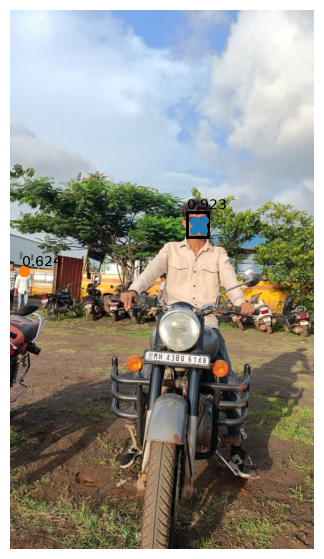

In [12]:
# Visualize the result
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(image_rgb)

if faces is not None:
    for face in faces:
        x, y, w, h = face[:4]
        confidence = face[14]

        # Bounding box
        rectangle = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )
        plt.gca().add_patch(rectangle)

        # Landmarks
        landmarks = face[4:14].reshape(5, 2)

        plt.scatter(
            landmarks[:, 0],
            landmarks[:, 1],
            s=30
        )

        plt.text(
            x,
            y - 5,
            f"{confidence:.3f}"
        )

plt.axis("off")
plt.show()

## Run YuNet over the Dataset

In [14]:
from pathlib import Path
import cv2
import pandas as pd

DATASET_DIR = Path("./Data/Classmates")
MODEL_PATH = Path("./models/face_detection_yunet_2026may.onnx")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Create detector
detector = cv2.FaceDetectorYN.create(
    model=str(MODEL_PATH),
    config="",
    input_size=(320, 320),
    score_threshold=0.6,
    nms_threshold=0.3,
    top_k=5000
)

results = []

for person_dir in sorted(DATASET_DIR.iterdir()):

    if not person_dir.is_dir():
        continue

    for image_path in sorted(person_dir.iterdir()):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        image = cv2.imread(str(image_path))

        record = {
            "person": person_dir.name,
            "filename": image_path.name,
            "path": str(image_path),
            "image_width": None,
            "image_height": None,
            "faces_detected": 0,
            "confidence": None,
            "face_x": None,
            "face_y": None,
            "face_width": None,
            "face_height": None,
            "landmarks": None,
        }

        if image is None:
            results.append(record)
            continue

        h, w = image.shape[:2]

        record["image_width"] = w
        record["image_height"] = h

        # IMPORTANT: width, height
        detector.setInputSize((w, h))

        _, faces = detector.detect(image)

        if faces is not None:

            record["faces_detected"] = len(faces)

            # For now, store the highest-confidence face
            best_face = max(faces, key=lambda f: f[14])

            x, y, fw, fh = best_face[:4]

            record["confidence"] = float(best_face[14])
            record["face_x"] = float(x)
            record["face_y"] = float(y)
            record["face_width"] = float(fw)
            record["face_height"] = float(fh)

            landmarks = best_face[4:14].reshape(5, 2)

            record["landmarks"] = landmarks.tolist()

        results.append(record)

df_yunet = pd.DataFrame(results)

print("Total images:", len(df_yunet))
print("Faces detected:",
      (df_yunet["faces_detected"] > 0).sum())
print("No face:",
      (df_yunet["faces_detected"] == 0).sum())

Total images: 256
Faces detected: 252
No face: 4


In [15]:
df_yunet.head()

,person,filename,path,image_width,image_height,faces_detected,confidence,face_x,face_y,face_width,face_height,landmarks
0,Abhishek_Halagi,AH1.jpeg,Data\Classmates\Abhishek_Halagi\AH1.jpeg,720,1280,1,0.942054,350.823944,259.711853,106.118309,137.303940,"[[372.6164855957031, 310.63531494140625], [426..."
1,Abhishek_Halagi,AH10.jpeg,Data\Classmates\Abhishek_Halagi\AH10.jpeg,720,1280,1,0.920856,348.917267,477.015869,54.202953,68.356598,"[[382.14935302734375, 503.6907653808594], [395..."
2,Abhishek_Halagi,AH11.jpeg,Data\Classmates\Abhishek_Halagi\AH11.jpeg,960,1280,1,0.923593,421.837769,524.328003,158.230087,178.565994,"[[455.00238037109375, 586.8036499023438], [526..."
3,Abhishek_Halagi,AH13.jpeg,Data\Classmates\Abhishek_Halagi\AH13.jpeg,960,1280,1,0.919814,434.489746,386.768250,67.521378,89.684235,"[[445.7046203613281, 416.21246337890625], [468..."
4,Abhishek_Halagi,AH14.jpeg,Data\Classmates\Abhishek_Halagi\AH14.jpeg,960,1280,1,0.955957,362.259186,359.148407,213.252792,250.137024,"[[422.00933837890625, 453.2929382324219], [523..."


In [16]:
### Checking success rate
total = len(df_yunet)

detected = (df_yunet["faces_detected"] > 0).sum()

print(f"Detection success: {detected}/{total}")
print(f"Success rate: {detected / total * 100:.2f}%")

Detection success: 252/256
Success rate: 98.44%


In [17]:
# image without dwtwctwd face
no_face = df_yunet[df_yunet["faces_detected"] == 0]

print(no_face[["person", "filename"]])

                 person   filename
25   Darshan_Khadakhadi  DK16.jpeg
74          Dhurvankur_    D7.jpeg
135       Pranav_Kavale   PK1.jpeg
215         Sahil_Patil  SP35.jpeg


In [18]:
# multiple face
multiple_faces = df_yunet[df_yunet["faces_detected"] > 1]

print("Images with multiple faces:",
      len(multiple_faces))

print(
    multiple_faces[
        ["person", "filename", "faces_detected"]
    ]
)

Images with multiple faces: 33
                  person   filename  faces_detected
16       Abhishek_Halagi   AH8.jpeg               2
26    Darshan_Khadakhadi  DK17.jpeg               2
37       Darshan_Netegal  DN11.jpeg               3
40       Darshan_Netegal  DN14.jpeg               3
41       Darshan_Netegal  DN15.jpeg               3
42       Darshan_Netegal  DN16.jpeg               5
45       Darshan_Netegal   DN3.jpeg               2
46       Darshan_Netegal   DN4.jpeg               2
71           Dhurvankur_    D4.jpeg               3
81    Harshad_Bhairatkar  HB13.jpeg               2
83    Harshad_Bhairatkar  HB15.jpeg               6
91    Harshad_Bhairatkar   HB4.jpeg               4
95    Harshad_Bhairatkar   HB8.jpeg               2
104        Mahesh_Oulkar   MO6.jpeg               2
108     Nikhil_Kanbarkar   NK1.jpeg               2
133     Nikhil_Kanbarkar   NK8.jpeg               2
139        Pranav_Kavale  PK13.jpeg               2
140        Pranav_Kavale   PK2.jp

In [19]:
df_yunet["confidence"].describe()

count    252.000000
mean       0.919485
std        0.039925
min        0.699163
25%        0.917465
50%        0.929249
75%        0.939493
max        0.959189
Name: confidence, dtype: float64

In [20]:
df_yunet[
    df_yunet["confidence"].notna()
].sort_values("confidence").head(15)

,person,filename,path,image_width,image_height,faces_detected,confidence,face_x,face_y,face_width,face_height,landmarks
103,Mahesh_Oulkar,MO5.jpeg,Data\Classmates\Mahesh_Oulkar\MO5.jpeg,864,1152,1,0.699163,439.444458,259.417084,287.513397,452.171204,"[[616.3829345703125, 430.69598388671875], [700..."
102,Mahesh_Oulkar,MO4.jpeg,Data\Classmates\Mahesh_Oulkar\MO4.jpeg,864,1152,1,0.717376,125.521973,230.708588,485.209167,612.463318,"[[155.03164672851562, 449.6922607421875], [399..."
97,Mahesh_Oulkar,MO1.jpeg,Data\Classmates\Mahesh_Oulkar\MO1.jpeg,864,1152,1,0.728525,261.841553,371.954285,329.171661,451.483490,"[[443.05731201171875, 514.6761474609375], [543..."
217,Sahil_Patil,SP37.jpeg,Data\Classmates\Sahil_Patil\SP37.jpeg,900,1600,1,0.730541,380.096863,608.534180,328.922577,372.819336,"[[462.13726806640625, 731.4150390625], [581.70..."
105,Mahesh_Oulkar,MO7.jpeg,Data\Classmates\Mahesh_Oulkar\MO7.jpeg,864,1152,1,0.734222,42.809280,313.216492,274.998535,433.540497,"[[59.823753356933594, 467.01788330078125], [10..."
70,Dhurvankur_,D3.jpeg,Data\Classmates\Dhurvankur_\D3.jpeg,960,1280,1,0.746934,708.230103,602.998901,86.405037,133.586060,"[[732.88427734375, 662.4765625], [726.75848388..."
218,Sahil_Patil,SP4.jpeg,Data\Classmates\Sahil_Patil\SP4.jpeg,900,1600,1,0.795050,372.611084,634.866638,410.167969,490.809418,"[[548.4239501953125, 687.760986328125], [738.3..."
136,Pranav_Kavale,PK10.jpeg,Data\Classmates\Pranav_Kavale\PK10.jpeg,899,1599,1,0.802752,290.378815,522.421387,432.775269,500.957733,"[[382.01580810546875, 646.1604614257812], [604..."
140,Pranav_Kavale,PK2.jpeg,Data\Classmates\Pranav_Kavale\PK2.jpeg,899,1599,2,0.810288,347.832062,598.358521,192.421402,225.435303,"[[408.0257873535156, 694.4824829101562], [470...."
26,Darshan_Khadakhadi,DK17.jpeg,Data\Classmates\Darshan_Khadakhadi\DK17.jpeg,899,1599,2,0.810288,347.832062,598.358521,192.421402,225.435303,"[[408.0257873535156, 694.4824829101562], [470...."


In [21]:
df_yunet["face_area_ratio"] = (
    df_yunet["face_width"] *
    df_yunet["face_height"]
) / (
    df_yunet["image_width"] *
    df_yunet["image_height"]
)

In [22]:
df_yunet["face_area_ratio"].describe()

count    252.000000
mean       0.033747
std        0.045082
min        0.000475
25%        0.004543
50%        0.015672
75%        0.040371
max        0.298568
Name: face_area_ratio, dtype: float64

In [23]:
df_yunet[
    df_yunet["face_width"].notna()
]["face_width"].describe()

count    252.000000
mean     154.488061
std      104.402195
min       26.312944
25%       67.658627
50%      127.421215
75%      209.353622
max      485.209167
Name: face_width, dtype: float64

In [26]:
# saving detected report
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df_yunet.to_csv(
    OUTPUT_DIR / "yunet_detection_report.csv",
    index=False
)

print("Report saved.")

Report saved.


In [25]:
best_face = max(faces, key=lambda f: f[14])

## Quality Check

YuNet detection
     ↓
1. Number of faces
2. Detection confidence
3. Face size
4. Face area relative to image
5. Blur/sharpness
6. Brightness
     ↓
ACCEPT / REVIEW / REJECT

In [27]:
import numpy as np

df_yunet["face_area_ratio"] = (
    df_yunet["face_width"] * df_yunet["face_height"]
) / (
    df_yunet["image_width"] * df_yunet["image_height"]
)

df_yunet["face_min_dimension"] = df_yunet[
    ["face_width", "face_height"]
].min(axis=1)

In [28]:
df_yunet[
    df_yunet["faces_detected"] > 0
][
    ["face_width", "face_height", "face_area_ratio", "face_min_dimension"]
].describe()

,face_width,face_height,face_area_ratio,face_min_dimension
count,252.000000,252.000000,252.000000,252.000000
mean,154.488061,199.981611,0.033747,154.158155
std,104.402195,137.601738,0.045082,104.451412
min,26.312944,34.623661,0.000475,26.312944
25%,67.658627,85.466757,0.004543,67.658627
50%,127.421215,160.974869,0.015672,124.873013
75%,209.353622,280.472054,0.040371,209.353622
max,485.209167,612.463318,0.298568,485.209167


In [29]:
# Check the smallest faces
small_faces = (
    df_yunet[df_yunet["faces_detected"] > 0]
    .sort_values("face_min_dimension")
)

small_faces[
    [
        "person",
        "filename",
        "face_width",
        "face_height",
        "face_min_dimension",
        "confidence"
    ]
].head(20)

,person,filename,face_width,face_height,face_min_dimension,confidence
242,Vishwanath_Muchandi,VM12.jpeg,26.312944,34.623661,26.312944,0.922243
195,Sahil_Patil,SP17.jpeg,30.469023,41.022053,30.469023,0.912856
214,Sahil_Patil,SP34.jpeg,31.239067,39.050243,31.239067,0.936181
222,Sahil_Patil,SP8.jpeg,32.730957,42.406025,32.730957,0.903517
227,Suraj_Mallur,SM12.jpeg,33.414070,39.866161,33.414070,0.931689
201,Sahil_Patil,SP22.jpeg,39.480259,50.083920,39.480259,0.930130
108,Nikhil_Kanbarkar,NK1.jpeg,39.589878,48.730614,39.589878,0.923408
165,Rohit_Patil,RP2.jpeg,39.746819,50.222458,39.746819,0.930643
207,Sahil_Patil,SP28.jpeg,40.054291,48.828468,40.054291,0.918332
200,Sahil_Patil,SP21.jpeg,41.046757,52.288589,41.046757,0.930415


In [30]:
# Calculate blur/sharpness
def calculate_blur_score(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return np.nan

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [31]:
# calculating for all images
blur_scores = []

for path in df_yunet["path"]:
    blur_scores.append(calculate_blur_score(path))

df_yunet["blur_score"] = blur_scores

In [32]:
#inspecting
df_yunet["blur_score"].describe()

count     256.000000
mean      510.264715
std       994.939575
min         4.421743
25%        85.859026
50%       202.009298
75%       481.658853
max      8248.962982
Name: blur_score, dtype: float64

### Calculating brightnesss

In [33]:
def calculate_brightness(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        return np.nan

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    return float(gray.mean())

In [34]:
df_yunet["brightness"] = [
    calculate_brightness(path)
    for path in df_yunet["path"]
]

In [35]:
df_yunet["brightness"].describe()

count    256.000000
mean     143.194974
std       30.996321
min       44.606522
25%      125.579626
50%      148.720839
75%      164.926243
max      216.156996
Name: brightness, dtype: float64

### Create Quality Summery

In [36]:
quality_columns = [
    "person",
    "filename",
    "faces_detected",
    "confidence",
    "face_width",
    "face_height",
    "face_min_dimension",
    "face_area_ratio",
    "blur_score",
    "brightness"
]

df_yunet[quality_columns].head(20)

,person,filename,faces_detected,confidence,face_width,face_height,face_min_dimension,face_area_ratio,blur_score,brightness
0,Abhishek_Halagi,AH1.jpeg,1,0.942054,106.118309,137.303940,106.118309,0.015810,165.981399,144.688671
1,Abhishek_Halagi,AH10.jpeg,1,0.920856,54.202953,68.356598,54.202953,0.004020,170.258259,191.133816
2,Abhishek_Halagi,AH11.jpeg,1,0.923593,158.230087,178.565994,158.230087,0.022994,135.412006,146.607354
3,Abhishek_Halagi,AH13.jpeg,1,0.919814,67.521378,89.684235,67.521378,0.004928,783.859979,140.804516
4,Abhishek_Halagi,AH14.jpeg,1,0.955957,213.252792,250.137024,213.252792,0.043410,224.787623,122.849003
5,Abhishek_Halagi,AH15.jpeg,1,0.946795,240.730392,284.156494,240.730392,0.055668,471.161230,101.416113
6,Abhishek_Halagi,AH16.jpeg,1,0.945451,128.141693,153.419022,128.141693,0.015999,1155.792219,131.602227
7,Abhishek_Halagi,AH17.jpeg,1,0.915844,51.673019,65.799210,51.673019,0.002767,421.010859,171.911651
8,Abhishek_Halagi,AH18.jpeg,1,0.948563,75.777557,93.802193,75.777557,0.006503,403.052803,147.518637
9,Abhishek_Halagi,AH19.jpeg,1,0.944172,135.194870,161.188110,135.194870,0.019935,91.514226,171.408162


In [38]:
# create initial categories

def classify_detection(row):

    # No face
    if row["faces_detected"] == 0:
        return "REJECT"

    # Multiple faces
    if row["faces_detected"] > 1:
        return "REVIEW"

    # Extremely small face
    if row["face_min_dimension"] < 40:
        return "REJECT"

    # Low detector confidence
    if row["confidence"] < 0.6:
        return "REVIEW"

    return "ACCEPT"

In [39]:
df_yunet["status"] = df_yunet.apply(
    classify_detection,
    axis=1
)

In [40]:
df_yunet["status"].value_counts()

status
ACCEPT    213
REVIEW     33
REJECT     10
Name: count, dtype: int64

### Analyse the results

In [41]:
df_yunet[
    ["person", "filename", "status"]
].groupby("status").size()

status
ACCEPT    213
REJECT     10
REVIEW     33
dtype: int64

In [42]:
df_yunet[
    df_yunet["status"] != "ACCEPT"
][quality_columns + ["status"]]

,person,filename,faces_detected,confidence,face_width,face_height,face_min_dimension,face_area_ratio,blur_score,brightness,status
16,Abhishek_Halagi,AH8.jpeg,2,0.932204,116.374039,160.755295,116.374039,0.015991,65.088615,165.967425,REVIEW
25,Darshan_Khadakhadi,DK16.jpeg,0,NaN,NaN,NaN,NaN,NaN,58.989645,150.376967,REJECT
26,Darshan_Khadakhadi,DK17.jpeg,2,0.810288,192.421402,225.435303,192.421402,0.030176,173.011783,131.761026,REVIEW
37,Darshan_Netegal,DN11.jpeg,3,0.948835,256.838654,331.938995,256.838654,0.039646,86.142859,113.279027,REVIEW
40,Darshan_Netegal,DN14.jpeg,3,0.944305,159.590302,118.022125,118.022125,0.022838,122.869591,128.555556,REVIEW
41,Darshan_Netegal,DN15.jpeg,3,0.944305,159.590302,118.022125,118.022125,0.022838,122.869591,128.555556,REVIEW
42,Darshan_Netegal,DN16.jpeg,5,0.946295,278.719482,371.711304,278.719482,0.072919,33.223708,121.683913,REVIEW
45,Darshan_Netegal,DN3.jpeg,2,0.939306,91.072426,116.158569,91.072426,0.013041,175.370319,123.476326,REVIEW
46,Darshan_Netegal,DN4.jpeg,2,0.935150,139.409332,175.840485,139.409332,0.029784,107.355884,128.239589,REVIEW
71,Dhurvankur_,D4.jpeg,3,0.949003,119.170685,160.761627,119.170685,0.015591,438.927641,141.585028,REVIEW


In [43]:
df_yunet.to_csv(
    "./outputs/face_quality_report.csv",
    index=False
)

In [44]:
df_yunet["status"].value_counts()

status
ACCEPT    213
REVIEW     33
REJECT     10
Name: count, dtype: int64

In [45]:
df_yunet["face_min_dimension"].describe()

count    252.000000
mean     154.158155
std      104.451412
min       26.312944
25%       67.658627
50%      124.873013
75%      209.353622
max      485.209167
Name: face_min_dimension, dtype: float64

In [46]:
df_yunet["blur_score"].describe()

count     256.000000
mean      510.264715
std       994.939575
min         4.421743
25%        85.859026
50%       202.009298
75%       481.658853
max      8248.962982
Name: blur_score, dtype: float64

In [47]:
df_yunet["brightness"].describe()

count    256.000000
mean     143.194974
std       30.996321
min       44.606522
25%      125.579626
50%      148.720839
75%      164.926243
max      216.156996
Name: brightness, dtype: float64

## Visual quality inspection

In [51]:
# Lowest blur score
df_yunet[
    df_yunet["faces_detected"] > 0
].sort_values("blur_score")[
    [
        "person",
        "filename",
        "blur_score",
        "confidence",
        "face_width",
        "face_height"
    ]
].head(20)

,person,filename,blur_score,confidence,face_width,face_height
63,Dhurvankur_,D2.jpeg,4.421743,0.919119,295.648010,393.018402
72,Dhurvankur_,D5.jpeg,11.581260,0.951770,187.278137,265.978516
143,Pranav_Kavale,PK5.jpeg,12.523569,0.919031,371.321503,454.623505
126,Nikhil_Kanbarkar,NK27.jpeg,19.108136,0.872277,443.935486,546.945923
64,Dhurvankur_,D20.jpeg,20.307155,0.842229,460.552002,590.145142
99,Mahesh_Oulkar,MO11.jpeg,21.079146,0.889041,354.809021,441.283630
193,Sahil_Patil,SP15.jpeg,21.234087,0.871915,199.629471,282.032501
66,Dhurvankur_,D23.jpeg,21.829879,0.932832,125.634628,177.450027
220,Sahil_Patil,SP6.jpeg,21.998137,0.911881,305.462952,413.145142
243,Vishwanath_Muchandi,VM13.jpeg,22.244489,0.934721,290.913666,395.151428


In [52]:

#lowest confidance
df_yunet[
    df_yunet["faces_detected"] > 0
].sort_values("confidence")[
    [
        "person",
        "filename",
        "confidence",
        "face_width",
        "face_height"
    ]
].head(20)

,person,filename,confidence,face_width,face_height
103,Mahesh_Oulkar,MO5.jpeg,0.699163,287.513397,452.171204
102,Mahesh_Oulkar,MO4.jpeg,0.717376,485.209167,612.463318
97,Mahesh_Oulkar,MO1.jpeg,0.728525,329.171661,451.483490
217,Sahil_Patil,SP37.jpeg,0.730541,328.922577,372.819336
105,Mahesh_Oulkar,MO7.jpeg,0.734222,274.998535,433.540497
70,Dhurvankur_,D3.jpeg,0.746934,86.405037,133.586060
218,Sahil_Patil,SP4.jpeg,0.795050,410.167969,490.809418
136,Pranav_Kavale,PK10.jpeg,0.802752,432.775269,500.957733
140,Pranav_Kavale,PK2.jpeg,0.810288,192.421402,225.435303
26,Darshan_Khadakhadi,DK17.jpeg,0.810288,192.421402,225.435303


In [53]:
# smallest face
df_yunet[
    df_yunet["faces_detected"] > 0
].sort_values("face_min_dimension")[
    [
        "person",
        "filename",
        "face_min_dimension",
        "face_width",
        "face_height",
        "confidence"
    ]
].head(20)

,person,filename,face_min_dimension,face_width,face_height,confidence
242,Vishwanath_Muchandi,VM12.jpeg,26.312944,26.312944,34.623661,0.922243
195,Sahil_Patil,SP17.jpeg,30.469023,30.469023,41.022053,0.912856
214,Sahil_Patil,SP34.jpeg,31.239067,31.239067,39.050243,0.936181
222,Sahil_Patil,SP8.jpeg,32.730957,32.730957,42.406025,0.903517
227,Suraj_Mallur,SM12.jpeg,33.414070,33.414070,39.866161,0.931689
201,Sahil_Patil,SP22.jpeg,39.480259,39.480259,50.083920,0.930130
108,Nikhil_Kanbarkar,NK1.jpeg,39.589878,39.589878,48.730614,0.923408
165,Rohit_Patil,RP2.jpeg,39.746819,39.746819,50.222458,0.930643
207,Sahil_Patil,SP28.jpeg,40.054291,40.054291,48.828468,0.918332
200,Sahil_Patil,SP21.jpeg,41.046757,41.046757,52.288589,0.930415


## Visual Quality Inspection

In [54]:
DATASET_DIR = Path("./Data/Classmates")
MODEL_PATH = Path("../models/face_detection_yunet_2026may.onnx")

In [55]:
import cv2
import matplotlib.pyplot as plt
import math

In [56]:
def show_quality_images(df, sort_by, n=12):
    """
    Display images with YuNet bounding boxes and 5 landmarks.
    """

    samples = (
        df[df["faces_detected"] > 0]
        .sort_values(sort_by)
        .head(n)
    )

    cols = 3
    rows = math.ceil(len(samples) / cols)

    plt.figure(figsize=(15, 5 * rows))

    for i, (_, row) in enumerate(samples.iterrows()):

        image = cv2.imread(row["path"])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image_rgb)

        # Bounding box
        x = row["face_x"]
        y = row["face_y"]
        w = row["face_width"]
        h = row["face_height"]

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rect)

        # Landmarks
        if row["landmarks"] is not None:

            landmarks = np.array(row["landmarks"])

            plt.scatter(
                landmarks[:, 0],
                landmarks[:, 1],
                s=25
            )

        plt.title(
            f"{row['person']} | {row['filename']}\n"
            f"{sort_by}: {row[sort_by]:.2f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# inspect the smallest faces
show_quality_images(
    df_yunet,
    sort_by="face_min_dimension",
    n=12
)

In [ ]:
# inspect the blurriest images
show_quality_images(
    df_yunet,
    sort_by="blur_score",
    n=12
)

In [1]:
# inspect lowest YuNet confidence
show_quality_images(
    df_yunet,
    sort_by="confidence",
    n=12
)

### Inspect the multi-face images

In [ ]:
show_quality_images(
    df_yunet[df_yunet["faces_detected"] > 1],
    sort_by="confidence",
    n=12
)

## Creating Clean Dataset

<p>FaceRecognition/<br>
│<br>
├── Data/<br>
├── Classmates/              ← ORIGINAL<br>
│<br>
└── Classmates_Clean/       ← USE THIS FOR ARCFace<br>
    ├── Abhishek_Halagi/<br>
    ├── Darshan_Khadakhadi/<br>
    ├── ...<br>
    └── Vishwanath_Muchandi/><br>
│<br>
├── models/<br>
│   └── face_detection_yunet_2026may.onnx<br>
│<br>
└── notebooks/</p><br>

In [62]:
from pathlib import Path
import shutil

CLEAN_DIR = Path("./Data/Classmates_Clean")

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

In [63]:
#Copy accepted images
accepted = df_yunet[df_yunet["status"] == "ACCEPT"]

for _, row in accepted.iterrows():

    person_dir = CLEAN_DIR / row["person"]
    person_dir.mkdir(parents=True, exist_ok=True)

    source = Path(row["path"])
    destination = person_dir / source.name

    shutil.copy2(source, destination)

print(f"Copied {len(accepted)} images.")

Copied 213 images.


In [64]:
#Create Review and Rejected folders
from pathlib import Path

REVIEW_DIR = Path("./Data/Classmates_Review")
REJECTED_DIR = Path("./Data/Classmates_Rejected")

REVIEW_DIR.mkdir(parents=True, exist_ok=True)
REJECTED_DIR.mkdir(parents=True, exist_ok=True)

In [65]:
# Review images
import shutil

reviewed = df_yunet[df_yunet["status"] == "REVIEW"]

for _, row in reviewed.iterrows():

    source = Path(row["path"])

    person_dir = REVIEW_DIR / row["person"]
    person_dir.mkdir(parents=True, exist_ok=True)

    destination = person_dir / source.name

    shutil.copy2(source, destination)

print(f"Copied {len(reviewed)} review images.")

Copied 33 review images.


In [66]:
# Move rejected images 
rejected = df_yunet[df_yunet["status"] == "REJECT"]

for _, row in rejected.iterrows():

    source = Path(row["path"])

    person_dir = REJECTED_DIR / row["person"]
    person_dir.mkdir(parents=True, exist_ok=True)

    destination = person_dir / source.name

    shutil.copy2(source, destination)

print(f"Copied {len(rejected)} rejected images.")

Copied 10 rejected images.


## REVIEW IMAGES

In [67]:
import cv2
import matplotlib.pyplot as plt
import math
import numpy as np

In [68]:
review_df = df_yunet[
    df_yunet["faces_detected"] > 1
].copy()

print("Review images:", len(review_df))

Review images: 33


In [69]:
def show_review_images(df, cols=4):

    rows = math.ceil(len(df) / cols)

    plt.figure(figsize=(20, rows * 5))

    for i, (_, row) in enumerate(df.iterrows()):

        image = cv2.imread(row["path"])

        if image is None:
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image_rgb)

        # Draw every detected face
        # Re-run YuNet because our dataframe only stores
        # the highest-confidence face.
        detector.setInputSize(
            (image.shape[1], image.shape[0])
        )

        _, faces = detector.detect(image)

        if faces is not None:

            for face in faces:

                x, y, w, h = face[:4]
                confidence = face[14]

                rect = plt.Rectangle(
                    (x, y),
                    w,
                    h,
                    fill=False,
                    linewidth=2
                )

                plt.gca().add_patch(rect)

                landmarks = face[4:14].reshape(5, 2)

                plt.scatter(
                    landmarks[:, 0],
                    landmarks[:, 1],
                    s=20
                )

                plt.text(
                    x,
                    max(y - 5, 0),
                    f"{confidence:.2f}",
                    fontsize=9
                )

        plt.title(
            f"{i + 1}. {row['person']}\n"
            f"{row['filename']} | Faces: {row['faces_detected']}",
            fontsize=10
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
show_review_images(review_df)

In [74]:
keep_review = {
    1,2,3,4,6,7,8,9,10,
    11,12,13,16,17,18,19,
    21,22,23,23,24,25,26,
    27,30,31,32,33
}

reject_review = {
    5,
    14,
    15,
    20,
    28,
    29
}

In [75]:
all_decisions = keep_review | reject_review

print("Total review images :", len(review_df))
print("Keep decisions      :", len(keep_review))
print("Reject decisions    :", len(reject_review))
print("Total decided       :", len(all_decisions))

missing = set(range(1, len(review_df) + 1)) - all_decisions

print("Undecided images    :", sorted(missing))

Total review images : 33
Keep decisions      : 27
Reject decisions    : 6
Total decided       : 33
Undecided images    : []


In [76]:
#Decision table
decision_records = []

for i, (_, row) in enumerate(review_df.iterrows(), start=1):

    if i in keep_review:
        decision = "KEEP"

    elif i in reject_review:
        decision = "REJECT"

    else:
        decision = "UNDECIDED"

    decision_records.append({
        "index": i,
        "person": row["person"],
        "filename": row["filename"],
        "faces_detected": row["faces_detected"],
        "confidence": row["confidence"],
        "decision": decision
    })

review_decisions = pd.DataFrame(decision_records)

review_decisions

,index,person,filename,faces_detected,confidence,decision
0,1,Abhishek_Halagi,AH8.jpeg,2,0.932204,KEEP
1,2,Darshan_Khadakhadi,DK17.jpeg,2,0.810288,KEEP
2,3,Darshan_Netegal,DN11.jpeg,3,0.948835,KEEP
3,4,Darshan_Netegal,DN14.jpeg,3,0.944305,KEEP
4,5,Darshan_Netegal,DN15.jpeg,3,0.944305,REJECT
5,6,Darshan_Netegal,DN16.jpeg,5,0.946295,KEEP
6,7,Darshan_Netegal,DN3.jpeg,2,0.939306,KEEP
7,8,Darshan_Netegal,DN4.jpeg,2,0.935150,KEEP
8,9,Dhurvankur_,D4.jpeg,3,0.949003,KEEP
9,10,Harshad_Bhairatkar,HB13.jpeg,2,0.933448,KEEP


In [ ]:
show_review_images(review_df)

In [81]:
keep_review = {
    1, 2, 3, 4, 6, 7, 8, 9, 10,
    11, 12, 13, 16, 17, 18, 19,
    21, 22, 23, 24, 25, 26, 27,
    30, 31, 32, 33
}

reject_review = {
    5, 14, 15, 20, 28, 29
}

In [82]:
print(keep_review)
print(reject_review)

{1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 30, 31, 32, 33}
{20, 5, 28, 29, 14, 15}


In [83]:
all_indices = set(range(1, len(review_df) + 1))

decided = keep_review | reject_review

print("Total review images :", len(review_df))
print("KEEP                :", len(keep_review))
print("REJECT              :", len(reject_review))
print("Total decided       :", len(decided))

missing = all_indices - decided

print("Undecided           :", sorted(missing))

Total review images : 33
KEEP                : 27
REJECT              : 6
Total decided       : 33
Undecided           : []


In [84]:
# copying keep images 
import shutil
from pathlib import Path

CLEAN_DIR = Path("./Data/Classmates_Clean")

for i, (_, row) in enumerate(review_df.iterrows(), start=1):

    if i not in keep_review:
        continue

    source = Path(row["path"])

    person_dir = CLEAN_DIR / row["person"]
    person_dir.mkdir(parents=True, exist_ok=True)

    destination = person_dir / source.name

    shutil.copy2(source, destination)

print(f"Added {len(keep_review)} review images to clean dataset.")

Added 27 review images to clean dataset.


In [85]:
# copying 6 rejected images
REJECTED_DIR = Path("./Data/Classmates_Rejected")

REJECTED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [86]:
for i, (_, row) in enumerate(review_df.iterrows(), start=1):

    if i not in reject_review:
        continue

    source = Path(row["path"])

    person_dir = REJECTED_DIR / row["person"]
    person_dir.mkdir(parents=True, exist_ok=True)

    destination = person_dir / source.name

    shutil.copy2(source, destination)

print(f"Added {len(reject_review)} images to rejected dataset.")

Added 6 images to rejected dataset.


In [87]:
# final clean dataset

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
}

clean_count = sum(
    1
    for p in CLEAN_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

rejected_count = sum(
    1
    for p in REJECTED_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

print("Clean images    :", clean_count)
print("Rejected images :", rejected_count)

Clean images    : 240
Rejected images : 16


In [88]:
# Check images/person

clean_counts = {}

for person_dir in sorted(CLEAN_DIR.iterdir()):

    if person_dir.is_dir():

        count = sum(
            1
            for p in person_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        clean_counts[person_dir.name] = count

clean_counts

{'Abhishek_Halagi': 18,
 'Darshan_Khadakhadi': 16,
 'Darshan_Netegal': 17,
 'Dhurvankur_': 23,
 'Harshad_Bhairatkar': 20,
 'Mahesh_Oulkar': 10,
 'Nikhil_Kanbarkar': 26,
 'Pranav_Kavale': 11,
 'Rohan_Kamble': 6,
 'Rohit_Patil': 27,
 'Sahil_Kurbet': 5,
 'Sahil_Patil': 32,
 'Suraj_Mallur': 14,
 'Vishwanath_Muchandi': 15}

In [89]:
clean_counts_df = pd.Series(
    clean_counts,
    name="clean_images"
)

print(clean_counts_df)

Abhishek_Halagi        18
Darshan_Khadakhadi     16
Darshan_Netegal        17
Dhurvankur_            23
Harshad_Bhairatkar     20
Mahesh_Oulkar          10
Nikhil_Kanbarkar       26
Pranav_Kavale          11
Rohan_Kamble            6
Rohit_Patil            27
Sahil_Kurbet            5
Sahil_Patil            32
Suraj_Mallur           14
Vishwanath_Muchandi    15
Name: clean_images, dtype: int64


# Face Alignment